In [1]:
import pandas as pd
import os
import numpy as np
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

In [2]:
from scipy.stats import pearsonr as corr

In [3]:
from scipy.stats import zscore

In [4]:
base = os.path.join(os.getcwd(),'..','compiled values')

In [5]:
gpp_grp = os.path.join(base,'gpp graphs')
os.makedirs(gpp_grp,exist_ok=True)

In [6]:
shapeFile = os.path.join(os.getcwd(),'..','shape','States_shapefile.shp')
shape = gpd.read_file(shapeFile)
shape['centroid']=shape.geometry.centroid
shape['x']=shape['centroid'].x
shape['FID_1'] = shape['x'].apply(lambda x:np.where(x<-100,1,0))
shape.drop(columns=['FID', 'Program', 'State_Code','Flowing_St', 'FID_1'],inplace=True)
shape.rename(columns={'State_Name':'State'},inplace=True)

In [7]:
lp_sd_ir = pd.read_excel(os.path.join(base,'sdate_irrigated_compiled.xlsx'))
lp_sd_rf = pd.read_excel(os.path.join(base,'sdate_rainfed_compiled.xlsx'))
rs_sd = pd.read_excel(os.path.join(base,'rs_sdate_clean.xlsx'))

In [8]:
rs_sd.drop(columns=['Unnamed: 0'],inplace=True)
rs_sd.rename(columns={'mean':'SD(RS)'},inplace=True)

In [9]:
lp_sd_ir['Mean(SO)'] = round(lp_sd_ir['Mean(SO)'])
lp_sd_rf['Mean(SO)'] = round(lp_sd_rf['Mean(SO)'])

In [10]:
lp_sd_ir.drop(columns=['Unnamed: 0'],inplace=True)
lp_sd_ir.rename(columns={'Mean(SO)':'SD(IR)','State':'State_Name','Date':'year'},inplace=True)

In [11]:
lp_sd_rf.drop(columns=['Unnamed: 0'],inplace=True)
lp_sd_rf.rename(columns={'Mean(SO)':'SD(RF)','State':'State_Name','Date':'year'},inplace=True)

In [12]:
def gen_index(df):
    if 'date' in df.columns:
        df['year']=df['date'].apply(lambda x:x.year)
        df.drop(columns=['date'],inplace=True)
    df['ival']=df['State_Name']+'-'+df['year'].astype(str)
    df.drop(columns=['State_Name','year'],inplace=True)
    return df

In [13]:
lp_sd_rf = gen_index(lp_sd_rf)
lp_sd_ir = gen_index(lp_sd_ir)
rs_sd = gen_index(rs_sd)

In [14]:
sd_compiled = pd.merge(lp_sd_rf,lp_sd_ir,on='ival')
sd_compiled = pd.merge(sd_compiled,rs_sd,on='ival')

In [15]:
sd_compiled['year']=sd_compiled['ival'].apply(lambda x:int(x.split('-')[1]))
sd_compiled['State']=sd_compiled['ival'].apply(lambda x:(x.split('-')[0]))
sd_compiled = sd_compiled.set_index('ival')

In [16]:
sd_mean =  sd_compiled.groupby(['State','year']).mean()
sd_mean = sd_mean.reset_index()

In [17]:
sd_compiled['Difference(RS-IR)'] = abs(sd_compiled['SD(IR)']-sd_compiled['SD(RS)'])
sd_compiled['Difference(RS-RF)'] = abs(sd_compiled['SD(RF)']-sd_compiled['SD(RS)'])

In [18]:
def corn_yield(df):
    df['Mean(SO)'] = round(df['Mean(SO)']/(0.45*0.01*100)/88,2)
    return df

In [19]:
lp_abgm_ir = corn_yield(pd.read_excel(os.path.join(base,'aboveground_biomassc_irrigated_compiled.xlsx')))
lp_abgm_rf = corn_yield(pd.read_excel(os.path.join(base,'aboveground_biomassc_rainfed_compiled.xlsx')))
rs_gpp = pd.read_excel(os.path.join(base,'CASA_yield.xlsx'))

In [20]:
rs_gpp['Yield(t/ha)[RS]'] = rs_gpp['RS_yield']/100

In [21]:
yield_data = pd.read_excel(os.path.join(base,'Corn_apy_data.xlsx'))

In [22]:
major_corn = yield_data[['LOCATION','PRODUCTION in BU']].groupby('LOCATION').mean()/10**6
major_corn = list(major_corn.sort_values(by='PRODUCTION in BU',ascending=False).index[:10])

In [23]:
yield_data = yield_data[['YEAR', 'LOCATION','YIELD in BU / ACRE']]

In [24]:
yield_data['Yield(t/ha)[USDA]']= yield_data['YIELD in BU / ACRE']*62.77/1000

In [25]:
# yield_data = yield_data[yield_data['LOCATION'].isin(major_corn)]

In [26]:

lp_abgm_ir.rename(columns={'Mean(SO)':'Yield(t/ha)[IR]','State':'State_Name'},inplace=True)
lp_abgm_ir['year']=lp_abgm_ir['date'].apply(lambda x:x.year)

lp_abgm_rf.rename(columns={'Mean(SO)':'Yield(t/ha)[RF]','State':'State_Name'},inplace=True)
lp_abgm_rf['year']=lp_abgm_rf['date'].apply(lambda x:x.year)

In [27]:
lp_abgm_rf = gen_index(lp_abgm_rf)
lp_abgm_ir = gen_index(lp_abgm_ir)
rs_gpp = gen_index(rs_gpp)
lp_abgm_rf.drop(columns=['Unnamed: 0'],inplace=True)
lp_abgm_ir.drop(columns=['Unnamed: 0'],inplace=True)

In [28]:
gpp_compiled = pd.merge(lp_abgm_rf,lp_abgm_ir,on='ival')
gpp_compiled = pd.merge(gpp_compiled,rs_gpp,on='ival')

In [29]:
gpp_compiled.drop(columns=['Unnamed: 0'],inplace=True)

In [30]:
yield_data['ival']=yield_data['LOCATION']+'-'+yield_data['YEAR'].astype(str)

In [37]:
final = pd.merge(sd_compiled,gpp_compiled,on='ival')

In [38]:
final = final.merge(yield_data,on='ival')
final['Condition'] = np.where(final['year']==2012,'Drought','Non-Drought')
final_mc = final[final['State'].isin(major_corn)]

In [39]:
def stats(df,x,y):
    df = df.dropna()
    xmod = df[x]
    xobs = df[y]
    xdiff=xmod-xobs
    NME = round(((np.sum(abs(xdiff)))/(np.sum(abs(np.mean(xobs)-(xobs))))),2)
    NMSE = round(((np.sum(np.square(xdiff)))/(np.sum(np.square(np.mean(xobs)-(xobs))))),2)

    z_m = zscore(xmod)
    z_o = zscore(xobs)
    cor = round(xmod.corr(xobs),2)
    count = len(xmod)
    return NME,NMSE,z_m,z_o,cor,count

In [71]:
final_mc.head()

,ival,SD(RF),SD(IR),SD(RS),year,State,Difference(RS-IR),Difference(RS-RF),Yield(t/ha)[RF],Yield(t/ha)[IR],RS_yield,Yield(t/ha)[RS],YEAR,LOCATION,YIELD in BU / ACRE,Yield(t/ha)[USDA],Condition
9,ILLINOIS-2010,91.0,121.0,115,2010,ILLINOIS,6.0,24.0,25.22,30.18,677.134776,6.771348,2010,ILLINOIS,157,9.85489,Non-Drought
10,INDIANA-2010,91.0,121.0,115,2010,INDIANA,6.0,24.0,23.54,29.47,582.127445,5.821274,2010,INDIANA,157,9.85489,Non-Drought
11,IOWA-2010,91.0,121.0,116,2010,IOWA,5.0,25.0,29.68,27.71,685.543076,6.855431,2010,IOWA,165,10.35705,Non-Drought
12,KANSAS-2010,91.0,120.0,115,2010,KANSAS,5.0,24.0,18.28,28.67,381.195325,3.811953,2010,KANSAS,124,7.78348,Non-Drought
17,MINNESOTA-2010,92.0,121.0,113,2010,MINNESOTA,8.0,21.0,22.20,26.91,583.621342,5.836213,2010,MINNESOTA,177,11.11029,Non-Drought


In [41]:
ls = []
ls.append(stats(final_mc,'Yield(t/ha)[IR]','Yield(t/ha)[USDA]'))
ls.append(stats(final_mc,'Yield(t/ha)[IR]','Yield(t/ha)[RS]'))
ls.append(stats(final_mc,'Yield(t/ha)[RF]','Yield(t/ha)[USDA]'))
ls.append(stats(final_mc,'Yield(t/ha)[RF]','Yield(t/ha)[RS]'))
ls.append(stats(final_mc,'Yield(t/ha)[USDA]','Yield(t/ha)[RS]'))
stats_df = pd.DataFrame(ls,index=['IR-USDA','IR-RS','RF-USDA','RF-RS','USDA-RS'],columns=['NME','NMSE','z_m','z_o','cor','count'])

In [42]:
stats_df[['NMSE','NME','cor']]

,NMSE,NME,cor
IR-USDA,112.58,12.84,-0.11
IR-RS,300.90,20.36,-0.10
RF-USDA,31.00,6.05,0.34
RF-RS,104.73,11.39,0.65
USDA-RS,13.67,4.34,0.58


In [43]:
df = final.copy()
col = 'Difference(RS-RF)'
data = df[col].dropna()
bins = np.linspace(data.min(), data.max(), 10)


df['bin_id'] = np.digitize(df[col], bins)

df_bins = pd.get_dummies(df['bin_id'], prefix='bin')

df_final = pd.concat([df, df_bins], axis=1)

In [44]:

bid= []
nme = []
nmse = []
z_m= []
z_o=[]
cor=[]
cat = []
count=[]

c1='Yield(t/ha)[RF]'
c2='Yield(t/ha)[RS]'

grp1 = df_final[df_final['year']!=2012].groupby('bin_id')
for d in grp1:
    bid.append(d[0])
    nme.append(stats(d[1],c1,c2)[0])
    nmse.append(stats(d[1],c1,c2)[1])
    z_m.append(stats(d[1],c1,c2)[2])
    z_o.append(stats(d[1],c1,c2)[3])
    cor.append(stats(d[1],c1,c2)[4])
    count.append(stats(d[1],c1,c2)[5])
    cat.append('Non-Drought')

grp2 = df_final[df_final['year']==2012].groupby('bin_id')
for d in grp2:
    bid.append(d[0])
    nme.append(stats(d[1],c1,c2)[0])
    nmse.append(stats(d[1],c1,c2)[1])
    z_m.append(stats(d[1],c1,c2)[2])
    z_o.append(stats(d[1],c1,c2)[3])
    cor.append(stats(d[1],c1,c2)[4])
    count.append(stats(d[1],c1,c2)[5])
    cat.append('Drought')


df = pd.DataFrame()
df['bin id']=bid
df['nme']=nme
df['nmse']=nmse
# df['z_m']=z_m
# df['z_o']=z_o
df['n_obs']=count
df['cor']=cor
df['Category']=cat
df['Type']='Rainfed'

In [45]:
rainfed = df.copy()

In [72]:
df

,bin id,nme,nmse,n_obs,cor,Category,Type
0,1,10.90,95.16,59,0.18,Non-Drought,Irrigated
1,2,13.01,133.06,56,-0.14,Non-Drought,Irrigated
2,3,9.44,79.81,59,-0.28,Non-Drought,Irrigated
3,4,8.71,72.28,50,0.02,Non-Drought,Irrigated
4,5,10.74,91.08,54,-0.14,Non-Drought,Irrigated
5,6,13.96,112.55,35,0.24,Non-Drought,Irrigated
6,7,29.99,533.18,18,0.12,Non-Drought,Irrigated
7,8,19.36,208.72,14,0.60,Non-Drought,Irrigated
8,9,88.73,4776.31,5,0.25,Non-Drought,Irrigated
9,10,inf,inf,1,NaN,Non-Drought,Irrigated


<Axes: xlabel='bin id', ylabel='nme'>

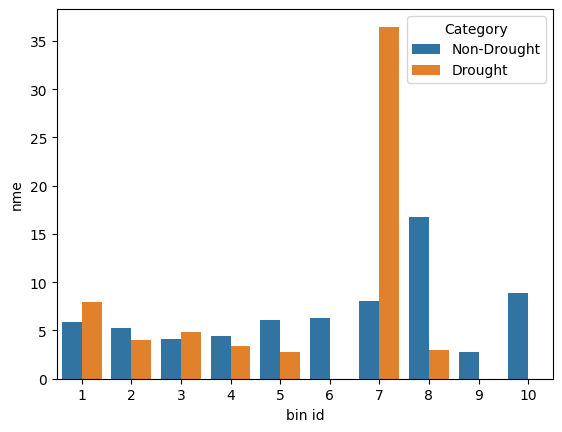

In [46]:
sns.barplot(data = df,x='bin id',y='nme',hue='Category')

In [47]:
np.round(bins,0)

array([ 0.,  6., 12., 18., 24., 29., 35., 41., 47., 53.])

In [48]:
df = final.copy()
col = 'Difference(RS-IR)'
data = df[col].dropna()
bins = np.linspace(data.min(), data.max(), 10)


df['bin_id'] = np.digitize(df[col], bins)

df_bins = pd.get_dummies(df['bin_id'], prefix='bin')

df_final = pd.concat([df, df_bins], axis=1)

bid= []
nme = []
nmse = []
z_m= []
z_o=[]
cor=[]
cat = []
count=[]

c1='Yield(t/ha)[IR]'
c2='Yield(t/ha)[RS]'

grp1 = df_final[df_final['year']!=2012].groupby('bin_id')
for d in grp1:
    bid.append(d[0])
    nme.append(stats(d[1],c1,c2)[0])
    nmse.append(stats(d[1],c1,c2)[1])
    z_m.append(stats(d[1],c1,c2)[2])
    z_o.append(stats(d[1],c1,c2)[3])
    cor.append(stats(d[1],c1,c2)[4])
    count.append(stats(d[1],c1,c2)[5])
    cat.append('Non-Drought')

grp2 = df_final[df_final['year']==2012].groupby('bin_id')
for d in grp2:
    bid.append(d[0])
    nme.append(stats(d[1],c1,c2)[0])
    nmse.append(stats(d[1],c1,c2)[1])
    z_m.append(stats(d[1],c1,c2)[2])
    z_o.append(stats(d[1],c1,c2)[3])
    cor.append(stats(d[1],c1,c2)[4])
    count.append(stats(d[1],c1,c2)[5])
    cat.append('Drought')


df = pd.DataFrame()
df['bin id']=bid
df['nme']=nme
df['nmse']=nmse
# df['z_m']=z_m
# df['z_o']=z_o
df['n_obs']=count
df['cor']=cor
df['Category']=cat
df['Type']='Irrigated'

In [49]:
irrigated = df.copy()

In [50]:
df_test = pd.concat([rainfed,irrigated],axis=0)

In [51]:
temp = df_test.dropna()

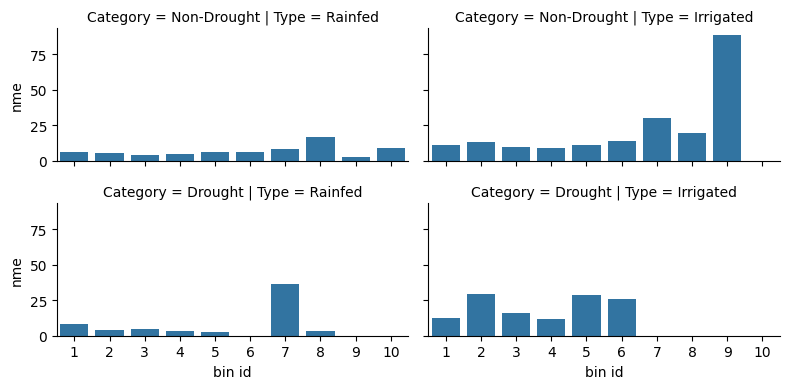

In [52]:
g = sns.FacetGrid(temp, col="Type",row='Category',height=2, aspect=2)
g.map(sns.barplot, "bin id", "nme")

In [53]:
df_test

,bin id,nme,nmse,n_obs,cor,Category,Type
0,1,5.86,30.69,31,0.81,Non-Drought,Rainfed
1,2,5.27,27.84,53,0.88,Non-Drought,Rainfed
2,3,4.14,19.41,62,0.93,Non-Drought,Rainfed
3,4,4.46,21.10,58,0.93,Non-Drought,Rainfed
4,5,6.09,33.22,54,0.84,Non-Drought,Rainfed
5,6,6.31,33.55,41,0.91,Non-Drought,Rainfed
6,7,8.04,45.51,28,0.90,Non-Drought,Rainfed
7,8,16.75,117.06,19,0.91,Non-Drought,Rainfed
8,9,2.77,8.94,3,0.99,Non-Drought,Rainfed
9,10,8.91,82.05,2,1.00,Non-Drought,Rainfed


<Axes: xlabel='bin id', ylabel='nme'>

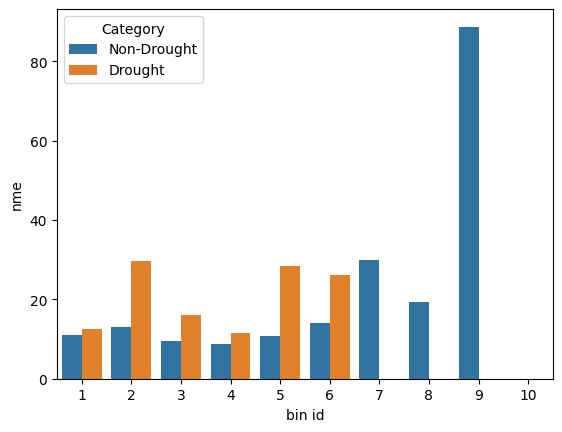

In [54]:
sns.barplot(data = df,x='bin id',y='nme',hue='Category')

In [55]:
np.round(bins,0)

array([ 0.,  5., 10., 15., 20., 26., 31., 36., 41., 46.])

In [56]:
final_mc = final[final['State'].isin(major_corn)]

In [57]:
final_mc_df = final_mc[['Yield(t/ha)[IR]','Yield(t/ha)[RF]', 'Yield(t/ha)[RS]', 'Yield(t/ha)[USDA]','YEAR']]

In [58]:
col1 = ['Yield(t/ha)[USDA]']
col2 = [ 'Yield(t/ha)[IR]','Yield(t/ha)[RF]', 'Yield(t/ha)[RS]']

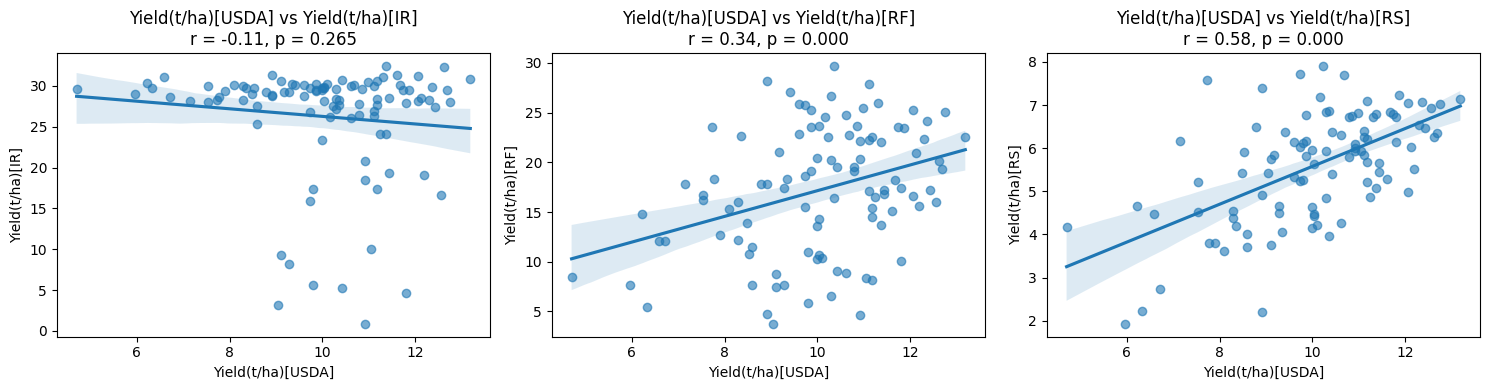

In [59]:
df_clean = final_mc_df.dropna()


nrows = len(col1)
ncols = len(col2)

fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))

for i, c1 in enumerate(col1):
    for j, c2 in enumerate(col2):
        ax = axes[i, j] if nrows > 1 else axes[j]
        
        x = df_clean[c1]
        y = df_clean[c2]
        
        r, p = corr(x, y)
        
        sns.regplot(x=x, y=y, ax=ax, scatter_kws={'alpha':0.6})
        
        ax.set_title(f"{c1} vs {c2}\nr = {r:.2f}, p = {p:.3f}")
        ax.set_xlabel(c1)
        ax.set_ylabel(c2)

plt.tight_layout()
fn = os.path.join(gpp_grp,'Correaltion_graph(LPJML-RS-USDA).png')
plt.savefig(fn, bbox_inches='tight',dpi=300)
plt.show()

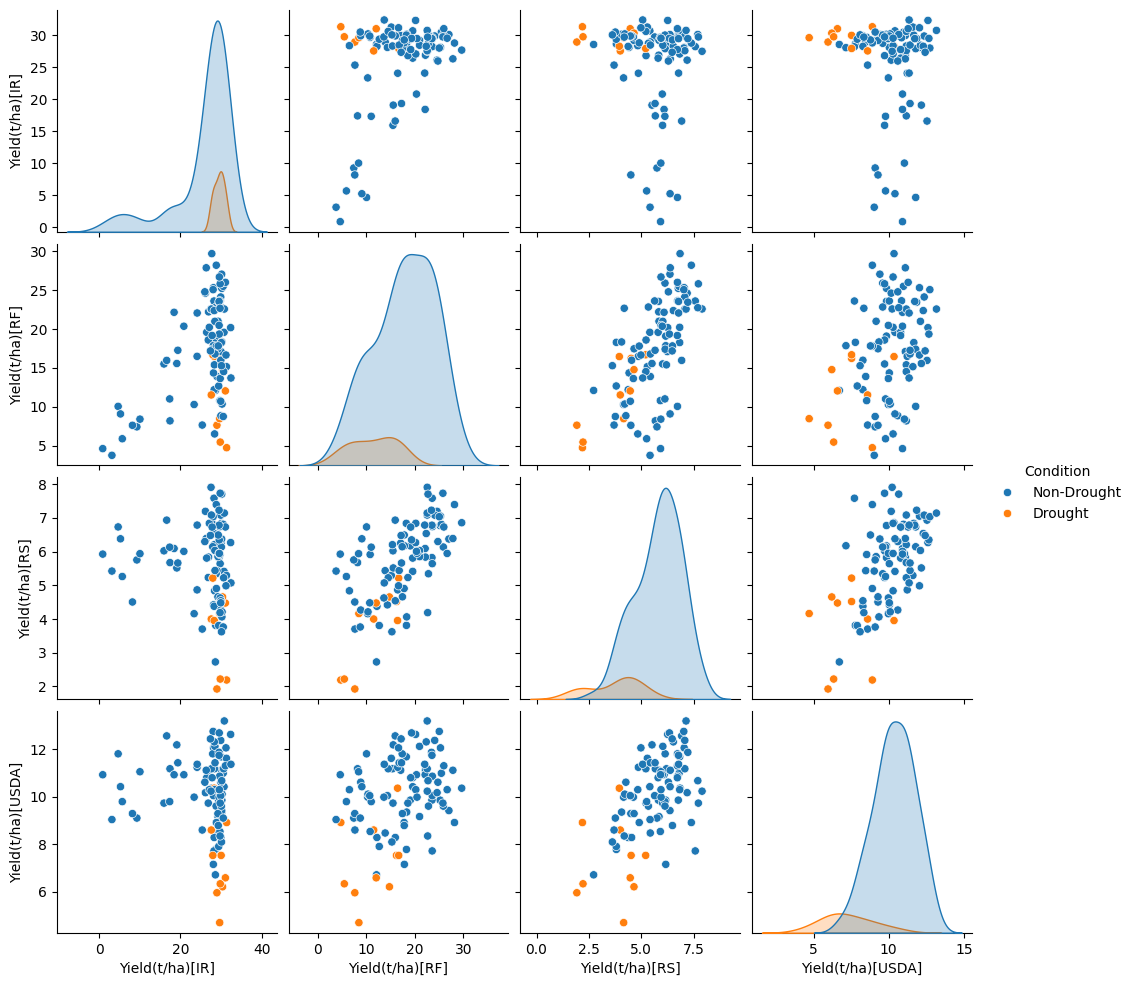

In [60]:
final_mc_pp = final_mc[['Yield(t/ha)[IR]','Yield(t/ha)[RF]', 'Yield(t/ha)[RS]', 'Yield(t/ha)[USDA]','Condition']]
sns.pairplot(data = final_mc_pp ,hue='Condition',diag_kind = 'kde')

In [61]:
final_mc_dr = final_mc[['Yield(t/ha)[IR]','Yield(t/ha)[RF]', 'Yield(t/ha)[RS]', 'Yield(t/ha)[USDA]','YEAR','Condition']]
# drought_df = final_mc_dr.groupby('YEAR').mean()

In [62]:
final_mc_melt = pd.melt(final_mc_dr,id_vars=['YEAR'],value_vars=['Yield(t/ha)[IR]','Yield(t/ha)[RF]', 'Yield(t/ha)[RS]', 'Yield(t/ha)[USDA]'],ignore_index=False)

In [63]:
final_mc_melt.rename(columns={'variable':'Parameter','value':'Yield'},inplace=True)


In [64]:
pdsi_values = pd.read_excel(os.path.join(base,'..','compiled values','PDSI_compiled.xlsx'))
pdsi_values.drop(columns=['Unnamed: 0','Date','Condition'],inplace=True)

In [65]:
pdsi = pdsi_values[(pdsi_values['State'].isin(major_corn)) & (pdsi_values['Month'].isin(range(4,11)))].drop(columns=['State','Month'])
value = pdsi.groupby('Year').mean()

In [66]:
value.head()

,pdsi
Year,
2010,2.838644
2011,2.989513
2012,-2.608312
2013,1.865114
2014,2.501483


<Axes: xlabel='Year', ylabel='pdsi'>

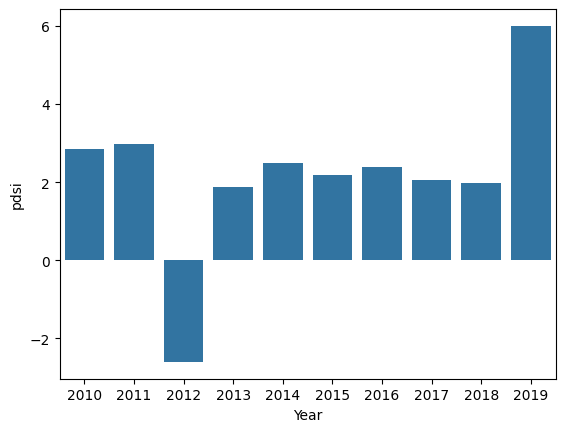

In [67]:
sns.barplot(data=value,x='Year',y='pdsi')

In [68]:
temp = final_mc_melt.groupby(['YEAR','Parameter']).mean()
temp = temp.reset_index()

<Axes: xlabel='YEAR', ylabel='Yield'>

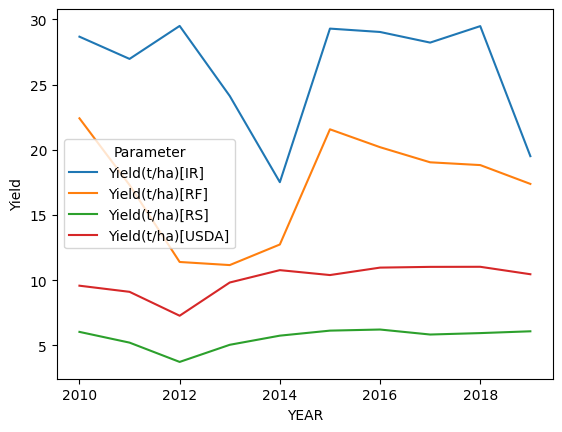

In [69]:
sns.lineplot(data=temp,x='YEAR',y='Yield',hue='Parameter')

In [70]:
# sns.boxplot(data = final_mc_melt,x='YEAR',y='Yield',hue='Parameter')